# MLPs for function regression on Yeh's concrete compresive strength database

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Nov 25, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.0 |
| Nov 25, 2025 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Improvements to code and comments |

Here, we will explore one of the most fundamental capabilities of neural networks: **function approximation**. We will focus on the **Concrete Compressive Strength** dataset. This dataset is available at:

https://archive.ics.uci.edu/dataset/165/concrete+compressive+strength


Concrete is complex; its strength depends on age and ingredients. We will use a neural network to learn this non-linear relationship.

-----

## Details on the dataset

**Reference paper:** I-Cheng Yeh (1998). *Modeling of strength of high-performance concrete using artificial neural networks*. Cement and Concrete Research, Vol. 28, No. 12.

* Number of instances: 1030
* Number of features: 8
* Number of targets: 1

| Variable Name                 | Role    | Type       | Units  | Description                                                                                                             |
| ----------------------------- | ------- | ---------- | ------ | ----------------------------------------------------------------------------------------------------------------------- |
| Cement                        | Feature | Continuous | kg/m^3 | The quantity of cement used in the concrete mixture, serving as the binding agent.                                      |
| Blast Furnace Slag            | Feature | Integer    | kg/m^3 | The amount of blast furnace slag, a supplementary cementitious material, enhancing durability and workability.          |
| Fly Ash                       | Feature | Continuous | kg/m^3 | The proportion of fly ash, a supplementary cementitious material, improving strength and reducing environmental impact. |
| Water                         | Feature | Continuous | kg/m^3 | The volume of water added to achieve desired consistency and hydration of cement particles.                             |
| Superplasticizer              | Feature | Continuous | kg/m^3 | The dosage of superplasticizer, an additive for enhanced workability and reduced water content.                         |
| Coarse Aggregate              | Feature | Continuous | kg/m^3 | The quantity of coarse aggregate (gravel/crushed stone) providing strength and stability to the mixture.                |
| Fine Aggregate                | Feature | Continuous | kg/m^3 | The amount of fine aggregate (sand or stone dust) used for filling voids and improving cohesion.                        |
| Age                           | Feature | Integer    | days   | The age of the concrete specimen at testing, affecting strength development over time.                                  |
| Concrete compressive strength | Target  | Continuous | MPa    | The compressive strength measured in MPa, representing resistance to axial loads.                                       |

The actual concrete compressive strength (MPa) for a given mixture under a
specific age (days) was determined from laboratory. Data is in raw form (not scaled).

-----

## 1. Data Acquisition

First, we must load the data.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load Dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
try:
    df = pd.read_excel(url)
except:
    raise Exception("Please ensure openpyxl is installed: pip install openpyxl")

# Let us visualize this dataset:
df.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [2]:
# Units for each variable
units = ['kg/m³', 'kg/m³', 'kg/m³', 'kg/m³', 'kg/m³', 'kg/m³', 'kg/m³', 'days', 'MPa']

# Clean column names
df.columns = df.columns.str.split('(', n=1).str[0] # Remove text after first '('
df.columns = df.columns.str.rstrip()               # Remove trailing whitespaces

df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age',
       'Concrete compressive strength'],
      dtype='object')

In [3]:
# Now let's find duplicated data
df.duplicated().sum()

np.int64(25)

In [4]:
# Remove duplicated data
df.drop_duplicates(keep="first", inplace = True, ignore_index = True)

In [5]:
# Le'ts see if there are missing values
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Concrete compressive strength,0


In [6]:
# Let's see the database
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cement                         1005 non-null   float64
 1   Blast Furnace Slag             1005 non-null   float64
 2   Fly Ash                        1005 non-null   float64
 3   Water                          1005 non-null   float64
 4   Superplasticizer               1005 non-null   float64
 5   Coarse Aggregate               1005 non-null   float64
 6   Fine Aggregate                 1005 non-null   float64
 7   Age                            1005 non-null   int64  
 8   Concrete compressive strength  1005 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 70.8 KB


## 1.1. Data analysis

In [7]:
# Let's see some statistics of the data
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
count,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000,1005.000000
mean,278.629055,72.043134,55.535075,182.074378,6.031647,974.376468,772.686617,45.856716,35.250273
std,104.345003,86.170555,64.207448,21.340740,5.919559,77.579534,80.339851,63.734692,16.284808
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,190.680000,0.000000,0.000000,166.610000,0.000000,932.000000,724.300000,7.000000,23.523542
50%,265.000000,20.000000,0.000000,185.700000,6.100000,968.000000,780.000000,28.000000,33.798114
75%,349.000000,142.500000,118.270000,192.940000,10.000000,1031.000000,822.200000,56.000000,44.868340
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


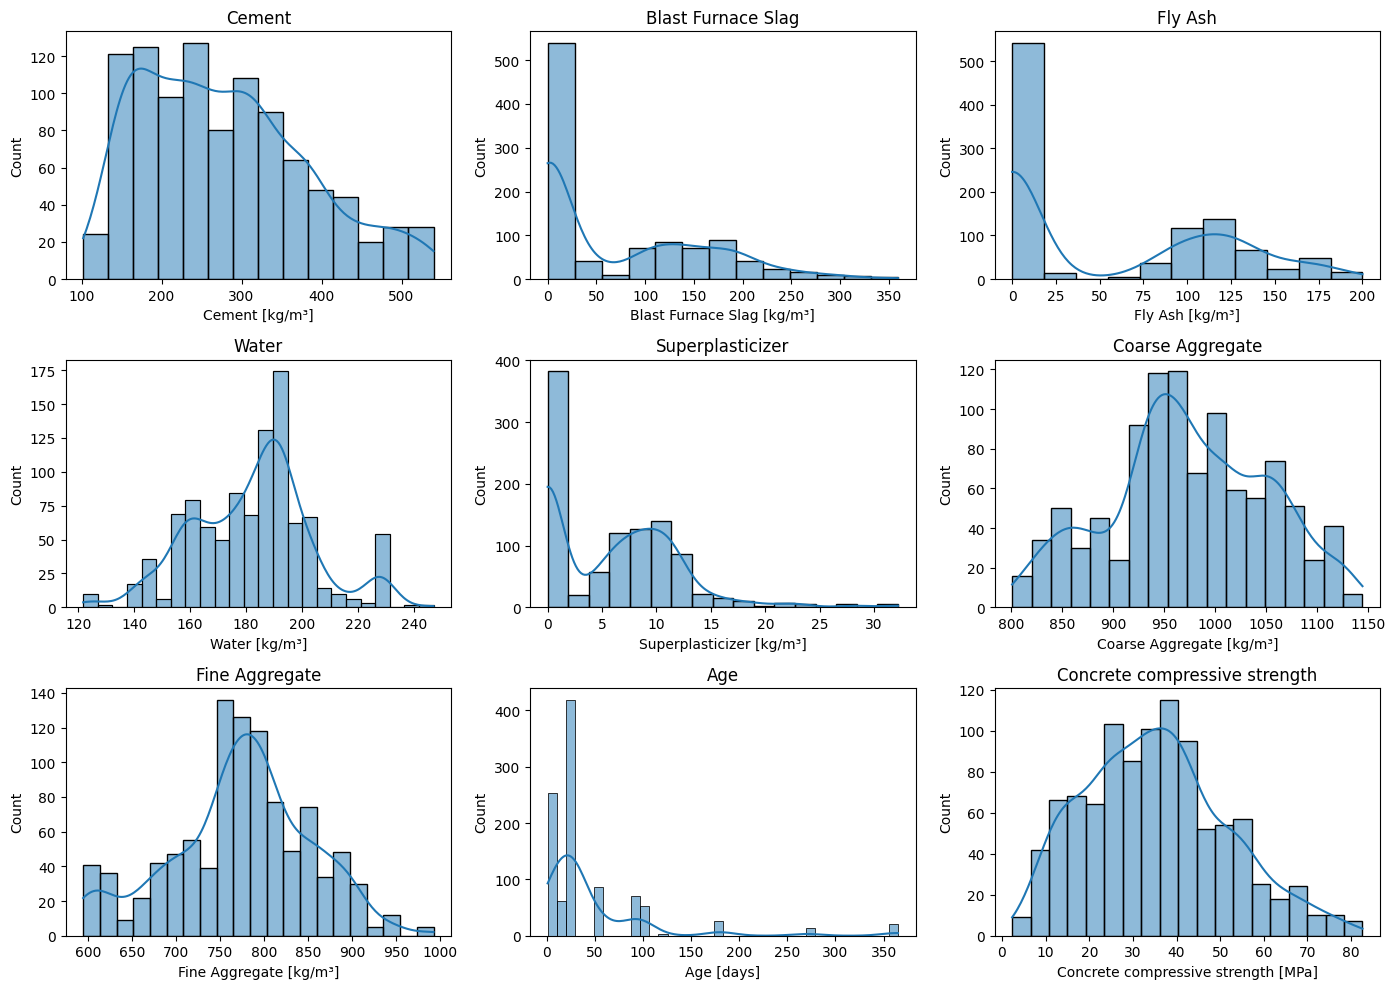

In [8]:
# Let's visualize the distribution of the data
plt.figure(figsize=(14,10))
for i, col in enumerate(df.columns, start=1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.xlabel(f"{col} [{units[df.columns.get_loc(col)]}]")
    plt.title(col)

plt.tight_layout() # Adjust subplot params for a tight layout
plt.show()

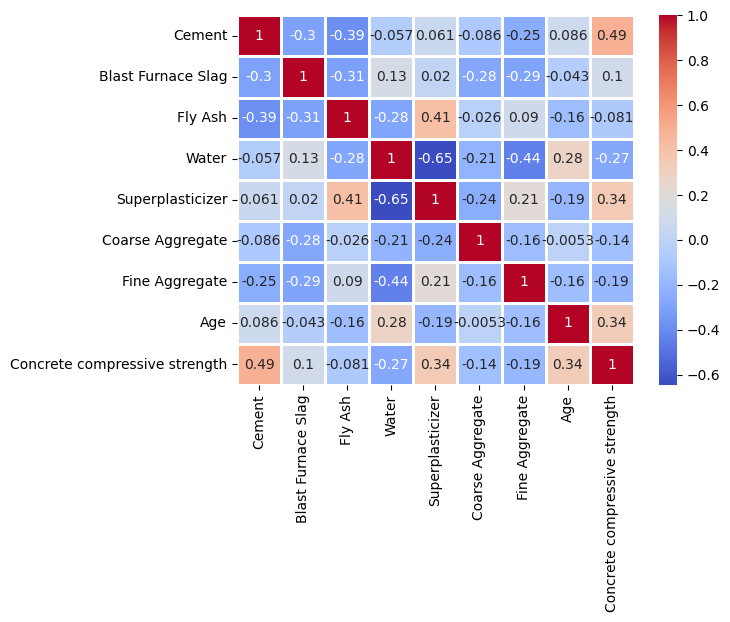

In [9]:
# Let's analyze the correlation matrix of data
sns.heatmap(df.corr(), annot=True, cmap = "coolwarm", linewidths=1)
plt.show()

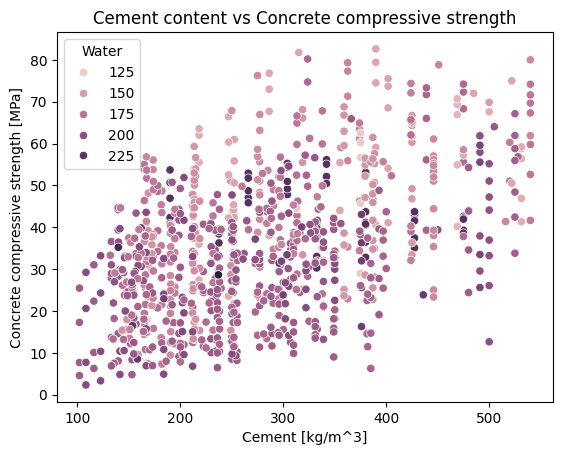

In [10]:
# As the cement content increases, so does the concrete compressive strength
sns.scatterplot(data=df, x="Cement", y="Concrete compressive strength", hue="Water")
plt.xlabel("Cement [kg/m^3]")
plt.ylabel("Concrete compressive strength [MPa]")
plt.title("Cement content vs Concrete compressive strength")
plt.show()

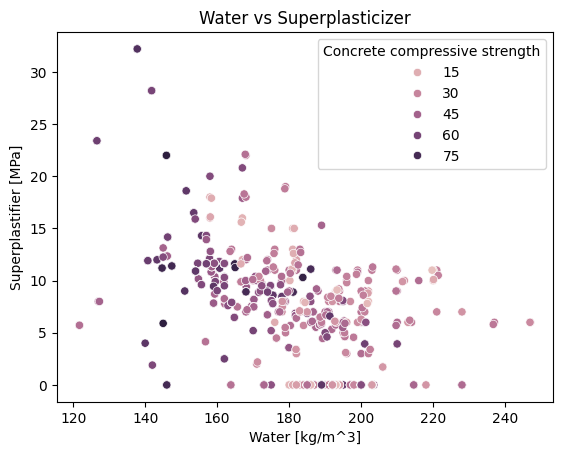

In [11]:
# As the water content decreases, we need to increase the amount of
# superplasticizer to achieve the required workability

# Superplasticizers optimize the use of water, ensuring sufficient workability
# for placement while minimizing the excess water that compromises
# the concrete's long-term performance.
sns.scatterplot(data=df, x="Water", y="Superplasticizer", hue="Concrete compressive strength")
plt.xlabel("Water [kg/m^3]")
plt.ylabel("Superplastifier [MPa]")
plt.title("Water vs Superplasticizer")
plt.show()

### 1.2. Data preprocessing

Now, we must prepare the data. Neural networks are sensitive to the scale of input features.

We will scale our data to the range $[-1, 1]$. Why? Because we are using hyperbolic tangent ($\tanh$) or similar activations, and centering the data helps keep the gradients well-conditioned during the early stages of backpropagation.

In [12]:
# Convert to numpy
X_raw = df.iloc[:,  :-1].values  # features (1030 x 8)
y_raw = df.iloc[:, [-1]].values  # f'c in MPa (1030 x 1)

print(f"Dataset shape: {X_raw.shape}")

# Scaling to [-1, 1]
scaler_x = MinMaxScaler(feature_range=(-1, 1))
scaler_y = MinMaxScaler(feature_range=(-1, 1))

X_scaled = scaler_x.fit_transform(X_raw)
y_scaled = scaler_y.fit_transform(y_raw)

# Convert to PyTorch Tensors
X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.FloatTensor(y_scaled)

# Split into training, validation and testing sets
VAL_PCT  = 0.10
TEST_PCT = 0.15
X_train_val, X_test, y_train_val, y_test = train_test_split(X_tensor,    y_tensor,    test_size=TEST_PCT)
X_train,     X_val,  y_train,     y_val  = train_test_split(X_train_val, y_train_val, test_size=VAL_PCT/(1-TEST_PCT))

print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")

Dataset shape: (1005, 8)
Train size: 753, Val size: 101, Test size: 151


## 2. Model Architecture and Initialization

We will define a flexible MLP class.

**Key Concepts:**

  * **Biases:** Included by default in `nn.Linear`.
  * **Xavier (Glorot) Initialization:** If weights are too small, signals vanish; if too large, they explode. Xavier initialization sets the variance of the weights based on the number of inputs and outputs ($n_{in}, n_{out}$) to keep signal variance constant across layers.

$$\operatorname{Var}(W) = \frac{2}{n_{in} + n_{out}}$$

In [13]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super(MLPRegressor, self).__init__()

        # We will use a standard 2-hidden-layer architecture
        self.layer1 = nn.Linear( input_dim, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)

        # Tanh pairs well with Xavier and [-1,1] scaling
        self.activation = nn.Tanh()

        # Apply Xavier Initialization
        self._init_weights()

    def _init_weights(self):
        # Iterate through modules and apply Xavier Uniform init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        x = self.activation(self.layer2(x))
        return self.output(x)

## 3. Defining the training function

This function implements:
1.  **Minibatches:** Online learning variation.
2.  **Gradient Norm Reporting:** To monitor stability.
3.  **Early Stopping:** To prevent overfitting.
4.  **Learning Rate Scheduling:** Strategies for step size.

In [14]:
def train_model(model, train_loader, val_loader,
                epochs=2000,
                patience=float('inf'), # deactivate by default
                loss_fn=nn.MSELoss(),
                optimizer_name='SGD',
                learning_rate=0.01):

    # Optimizer
    match optimizer_name:
        case 'SGD':
            optimizer = torch.optim.SGD(    model.parameters(), lr=learning_rate)
        case 'Momentum':
            optimizer = torch.optim.SGD(    model.parameters(), lr=learning_rate, momentum=0.9)
        case 'Adam':
            optimizer = torch.optim.Adam(   model.parameters(), lr=learning_rate)
        case 'RMSprop':
            optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate)
        case _:
            raise ValueError(f"Unknown optimizer: {optimizer_name}")

    # Step size scheduler
    # Reduces LR if validation loss plateaus
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=20)

    # History tracking
    history = {'train_loss': [], 'val_loss': [], 'grad_norm': [], 'lr': []}

    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    print(f"--- Starting Training ({optimizer_name}) ---")

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        # --- Online Learning with Minibatches ---
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()

            # Record Gradient Norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item()**2
            total_norm = total_norm ** 0.5

            optimizer.step()
            epoch_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss /= len(train_loader.dataset)

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = loss_fn(outputs, targets)
                epoch_val_loss += loss.item() * inputs.size(0)
        epoch_val_loss /= len(val_loader.dataset)

        # Step the scheduler
        scheduler.step(epoch_val_loss)

        # Save history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'  ].append(epoch_val_loss)
        history['grad_norm' ].append(total_norm) # Saving the norm of the last batch of the epoch
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # --- Reporting every 100 epochs ---
        if (epoch) % 100 == 0:
            print(f"   "
                  f"Epoch {epoch:5d} | "
                  f"Loss: {epoch_train_loss:.5f} | "
                  f"Val Loss: {epoch_val_loss:.5f} | "
                  f"Grad Norm: {total_norm:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        # --- Early Stopping Criteria ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"   Early stopping triggered at epoch {epoch}")
                model.load_state_dict(best_model_state)
                break

    return history

## 4. Training Execution and Visualization

Let's run the training using a batch size of $k=32$ (minibatch SGD) and visualize the results.

--- Starting Training (Adam) ---
   Epoch     0 | Loss: 0.16426 | Val Loss: 0.08867 | Grad Norm: 0.8701 | LR: 0.010000
   Epoch   100 | Loss: 0.01594 | Val Loss: 0.01955 | Grad Norm: 0.2759 | LR: 0.010000
   Epoch   200 | Loss: 0.01090 | Val Loss: 0.01705 | Grad Norm: 0.1665 | LR: 0.000313
   Epoch   300 | Loss: 0.01074 | Val Loss: 0.01715 | Grad Norm: 0.0801 | LR: 0.000020
   Epoch   400 | Loss: 0.01073 | Val Loss: 0.01713 | Grad Norm: 0.1379 | LR: 0.000001
   Early stopping triggered at epoch 413


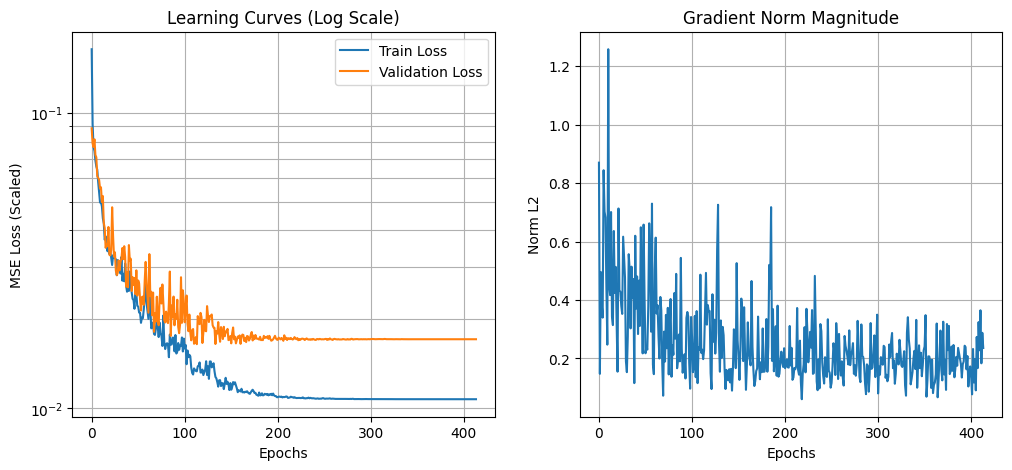

Final Test MSE (Scaled): 0.01816
Final Test MSE (Real Units - MPa^2): 29.25


In [15]:
# Configuration
BATCH_SIZE    = 32
HIDDEN_DIM    = 15
LEARNING_RATE = 0.01

# DataLoaders
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)

# Shuffle = True implements the stochastic nature required
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

# Initialize Model
model = MLPRegressor(input_dim=X_train.shape[1], hidden_dim=HIDDEN_DIM, output_dim=1)

# Loss function
loss_fn = nn.MSELoss()

# Train
history = train_model(model, train_loader, val_loader,
                      epochs=5000,
                      patience=300,
                      loss_fn=loss_fn,
                      optimizer_name='Adam', # Switch to 'SGD', 'Momentum', 'Adam', 'RMSprop' here
                      learning_rate=LEARNING_RATE)

# --- Plotting Learning Curves ---
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history[  'val_loss'], label='Validation Loss')
plt.yscale('log')
plt.title('Learning Curves (Log Scale)')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss (Scaled)')
plt.legend()
plt.grid(True, which="both", ls="-")

# Gradient Norm Curve
plt.subplot(1, 2, 2)
plt.plot(history['grad_norm'])
#plt.yscale('log')
plt.title('Gradient Norm Magnitude')
plt.xlabel('Epochs')
plt.ylabel('Norm L2')
plt.grid(True, which="both", ls="-")

plt.show()

# --- Estimate Test Error ---
model.eval()
with torch.no_grad():
    predictions = model(X_test)
    test_mse = loss_fn(predictions, y_test).item()

print(f"Final Test MSE (Scaled): {test_mse:.5f}")

# Inverse transform to get real error (Concrete Strength in MPa)
preds_unscaled  = scaler_y.inverse_transform(predictions.numpy())
y_test_unscaled = scaler_y.inverse_transform(y_test.numpy())
real_mse = loss_fn(torch.from_numpy(preds_unscaled), torch.from_numpy(y_test_unscaled)).item()
print(f"Final Test MSE (Real Units - MPa^2): {real_mse:.2f}")

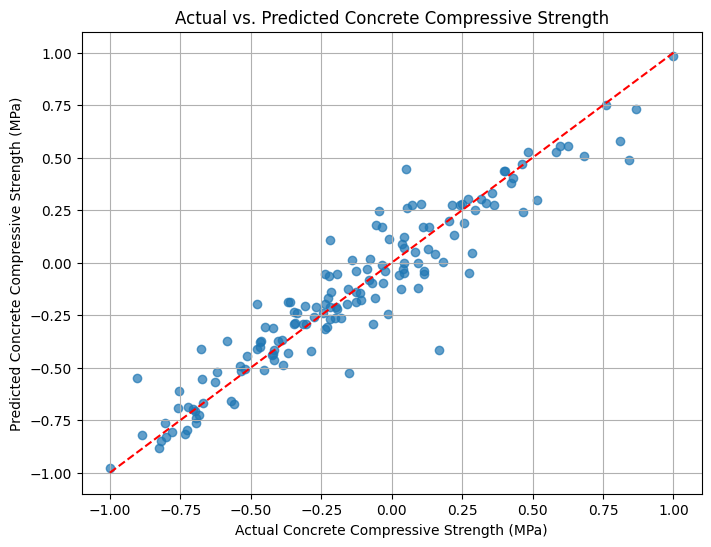

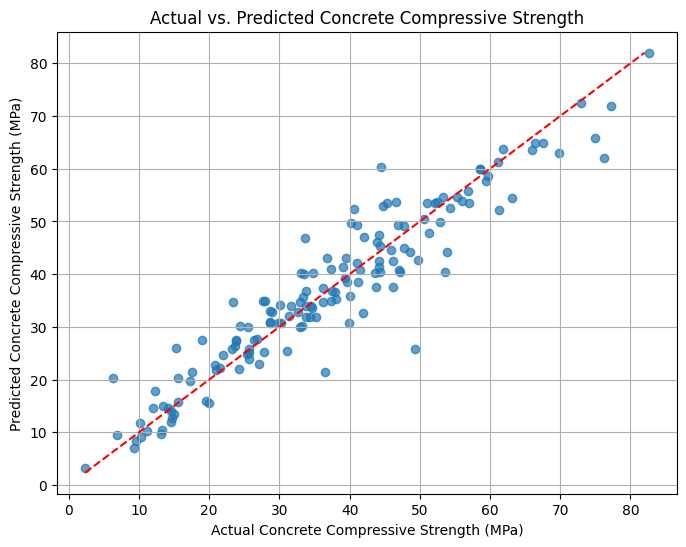

R2 Score: 0.8933


In [16]:
from sklearn.metrics import r2_score

# Create scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(y_test.numpy(), predictions.numpy(), alpha=0.7)
plt.plot([-1, 1], [-1, 1], 'r--') # Identity line
plt.xlabel("Actual Concrete Compressive Strength (MPa)")
plt.ylabel("Predicted Concrete Compressive Strength (MPa)")
plt.title("Actual vs. Predicted Concrete Compressive Strength")
plt.grid(True)
plt.show()

# Create scatterplot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_unscaled, preds_unscaled, alpha=0.7)
plt.plot([min(y_test_unscaled), max(preds_unscaled)], [min(y_test_unscaled), max(preds_unscaled)], 'r--') # Identity line
plt.xlabel("Actual Concrete Compressive Strength (MPa)")
plt.ylabel("Predicted Concrete Compressive Strength (MPa)")
plt.title("Actual vs. Predicted Concrete Compressive Strength")
plt.grid(True)
plt.show()

# Calculate R2 Score
r2 = r2_score(y_test_unscaled, preds_unscaled)
print(f"R2 Score: {r2:.4f}")




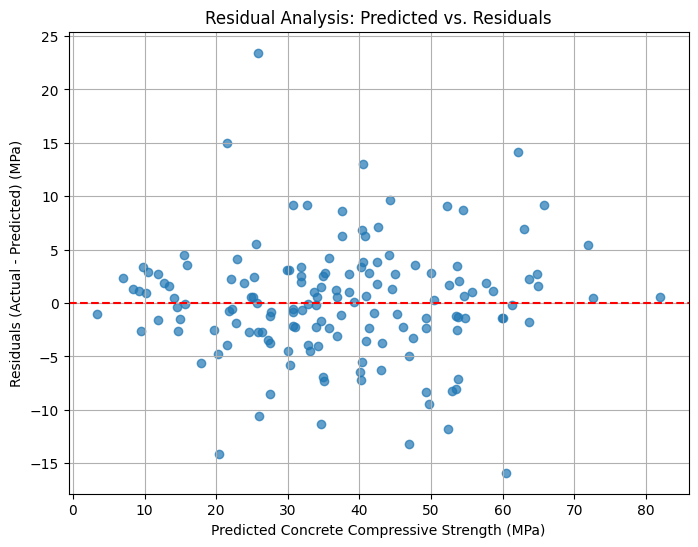

R2 Score: -5.6967


In [17]:
# Residual analysis plot
residuals = y_test_unscaled - preds_unscaled

plt.figure(figsize=(8, 6))
plt.scatter(preds_unscaled, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at 0 for reference
plt.xlabel("Predicted Concrete Compressive Strength (MPa)")
plt.ylabel("Residuals (Actual - Predicted) (MPa)")
plt.title("Residual Analysis: Predicted vs. Residuals")
plt.grid(True)
plt.show()

# Calculate R2 Score
r2 = r2_score(preds_unscaled, residuals)
print(f"R2 Score: {r2:.4f}")

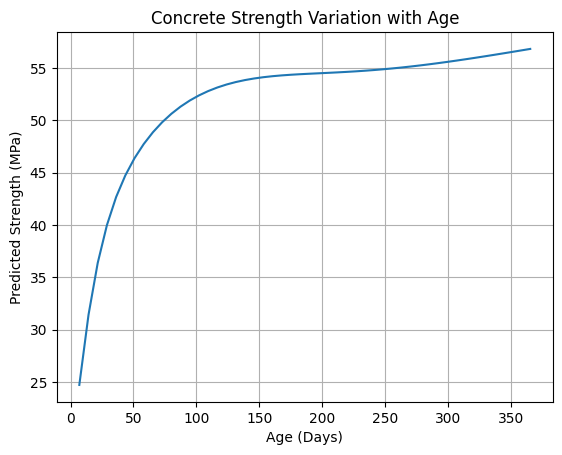

In [18]:
# Let's use this MLP to see how the concrete strength varies with age
n_ages = 50
age_range = np.linspace(7, 365, n_ages)

# Create a DataFrame with the mean of only these specific feature columns, duplicated 50 times
simulated_data_df = df.mean().to_frame().T.iloc[[0]*n_ages]

# Now set the age range, overwriting the mean age in the 'Age' column
simulated_data_df['Age'] = age_range

# Remove the "Concrete compressive strength" column
simulated_data_df.drop("Concrete compressive strength", axis=1, inplace=True)

# Convert to numpy array
simulated_data_np = simulated_data_df.values

# Scale the simulated data using the previously fitted scaler_x
simulated_data_scaled = scaler_x.transform(simulated_data_np)

# Convert to PyTorch Tensor
simulated_data_tensor = torch.FloatTensor(simulated_data_scaled)

# Make predictions using the trained model
model.eval() # Set model to evaluation mode
with torch.no_grad():
    predictions_scaled = model(simulated_data_tensor)

# Inverse transform predictions to get real MPa values
preds_unscaled = scaler_y.inverse_transform(predictions_scaled.numpy())

plt.figure()
plt.plot(age_range, preds_unscaled)
plt.xlabel("Age (Days)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Concrete Strength Variation with Age")
plt.grid()
plt.show()

## 5. K-Fold Cross-Validation for Model Selection

K-Fold Cross-Validation is a powerful technique used to assess the generalization capability and robustness of a machine learning model, especially when the dataset size is limited.

### What is K-Fold Cross-Validation?

Instead of a single train/validation split, K-Fold Cross-Validation divides the entire dataset into `k` equally sized 'folds' or subsets. The process then involves `k` iterations:

1.  **For each iteration (or fold):**
    *   One of the `k` folds is designated as the **validation set**.
    *   The remaining `k-1` folds are combined to form the **training set**.
2.  A model is trained on this new training set and evaluated on the designated validation set.
3.  This process is repeated `k` times, ensuring that **each fold serves as the validation set exactly once**.

### Why use K-Fold Cross-Validation?

The primary purposes of K-Fold Cross-Validation are:

1.  **More Reliable Performance Estimate:** By averaging the performance metrics (e.g., MSE, accuracy) from each of the `k` iterations, we obtain a more stable and less biased estimate of the model's true performance on unseen data. A single train/validation split can be sensitive to the particular random division, potentially leading to an overly optimistic or pessimistic evaluation.
2.  **Better Hyperparameter Tuning:** When tuning hyperparameters (like `hidden_dim`, `learning_rate`, or `patience` in our case), K-Fold CV helps select hyperparameters that perform well across different subsets of the data, rather than just optimizing for one specific validation set. This makes the chosen hyperparameters more robust.
3.  **Utilizing More Data for Training:** In each iteration, a large portion of the data (k-1 folds) is used for training, which helps the model learn more effectively from the available information.
4.  **Assessing Model Robustness:** It allows us to observe how consistently the model performs across different data partitions, highlighting potential sensitivity to specific data points or distributions within the dataset. If the performance varies wildly between folds, it indicates a less robust model or a very heterogeneous dataset.

In essence, K-Fold Cross-Validation helps us ensure that our model's performance isn't just a fluke of a particular data split, but a more generalizable capability.

Let use it to determine the robustness of our hyperparameters:

In [19]:
def run_kfold_cv(k=5, hidden_dim=30, loss_fn=nn.MSELoss(), optimizer_name='Adam', patience=300):
    kfold = KFold(n_splits=k, shuffle=True)
    CV_errors = []
    test_errors = []

    print(f"\n--- Running {k}-Fold Cross-Validation ---")

    for fold, (train_ids, val_ids) in enumerate(kfold.split(X_train_val)):
        # Sample elements
        X_sub_train = X_train_val[train_ids]
        y_sub_train = y_train_val[train_ids]
        X_sub_val   = X_train_val[  val_ids]
        y_sub_val   = y_train_val[  val_ids]

        # Loader
        sub_train_loader = DataLoader(TensorDataset(X_sub_train, y_sub_train), batch_size=32, shuffle=True)
        sub_val_loader   = DataLoader(TensorDataset(X_sub_val,   y_sub_val),   batch_size=32)

        # Init new model
        MLP = MLPRegressor(input_dim=X_train_val.shape[1], hidden_dim=hidden_dim)

        # Train (Silent mode mostly)
        history = train_model(MLP, sub_train_loader, sub_val_loader,
                              epochs=5000,
                              patience=patience,
                              loss_fn=loss_fn,
                              optimizer_name=optimizer_name,
                              learning_rate=0.01)

        best_loss = min(history['val_loss'])
        CV_errors.append(best_loss)
        print(f"   Fold {fold+1} Best Val MSE: {best_loss:.5f}")

        test_errors.append(loss_fn(MLP(X_test), y_test).item())

    avg_loss       = np.mean(CV_errors)
    std_loss       = np.std(CV_errors)
    avg_test_error = np.mean(test_errors)
    std_test_error = np.std(test_errors)

    print(f"Average CV MSE: {avg_loss:.5f} +/- {std_loss:.5f}; "
          f"Average TE MSE: {avg_test_error:.5f} +/- {std_test_error:.5f}")

    return avg_loss, std_loss, avg_test_error, std_test_error

# Execute CV
# run_kfold_cv(hidden_dim=5)

-----

### 6. Model selection

Now for something fascinating. According to classical statistics, making a model too complex (too many parameters) leads to overfitting (high variance). However, modern Deep Learning shows a "Double Descent."

As we increase model complexity (Hidden Size), the test error drops, rises (overfitting), and then **drops again** as the model becomes massively over-parameterized and enters the "interpolation regime."

*Note: This experiment requires training many models. It may take a few minutes.*

Now, let's implement a function `vary_number_of_hidden_neurons` that performs K-Fold Cross-Validation (using the existing `run_kfold_cv` function) for a given list of `hidden_sizes`.

In [20]:
def vary_number_of_hidden_neurons(hidden_sizes):
    mean_cv_errors   = []
    std_cv_errors    = []
    mean_test_errors = []
    std_test_errors  = []

    print("\n--- Exploring the errors as we change the number of hidden neurons ---")

    for h_dim in hidden_sizes:
        print(f"\nRunning CV for hidden_dim: {h_dim}")
        avg_loss, std_loss, avg_te, std_te = run_kfold_cv(hidden_dim=h_dim)
        mean_cv_errors.append(avg_loss)
        std_cv_errors.append(std_loss)
        mean_test_errors.append(avg_te)
        std_test_errors.append(std_te)

    return mean_cv_errors, std_cv_errors, mean_test_errors, std_test_errors

Now, let's generate a plot showing the mean validation MSE with error bars (representing the standard deviation) against the `hidden_sizes` to visualize the double descent phenomenon using cross-validation.

This will lead to a plot providing insights into model complexity versus performance.


--- Exploring the errors as we change the number of hidden neurons ---

Running CV for hidden_dim: 1

--- Running 5-Fold Cross-Validation ---
--- Starting Training (Adam) ---
   Epoch     0 | Loss: 0.37468 | Val Loss: 0.23807 | Grad Norm: 1.1087 | LR: 0.010000
   Epoch   100 | Loss: 0.05044 | Val Loss: 0.05625 | Grad Norm: 0.2221 | LR: 0.010000
   Epoch   200 | Loss: 0.04971 | Val Loss: 0.05327 | Grad Norm: 0.2002 | LR: 0.002500
   Epoch   300 | Loss: 0.04930 | Val Loss: 0.05386 | Grad Norm: 0.3164 | LR: 0.000078
   Epoch   400 | Loss: 0.04930 | Val Loss: 0.05390 | Grad Norm: 0.5193 | LR: 0.000002
   Early stopping triggered at epoch 482
   Fold 1 Best Val MSE: 0.05267
--- Starting Training (Adam) ---
   Epoch     0 | Loss: 0.25860 | Val Loss: 0.23958 | Grad Norm: 0.5013 | LR: 0.010000
   Epoch   100 | Loss: 0.04988 | Val Loss: 0.05665 | Grad Norm: 0.2839 | LR: 0.010000
   Epoch   200 | Loss: 0.04847 | Val Loss: 0.05687 | Grad Norm: 0.1432 | LR: 0.000313
   Epoch   300 | Loss: 0.04840

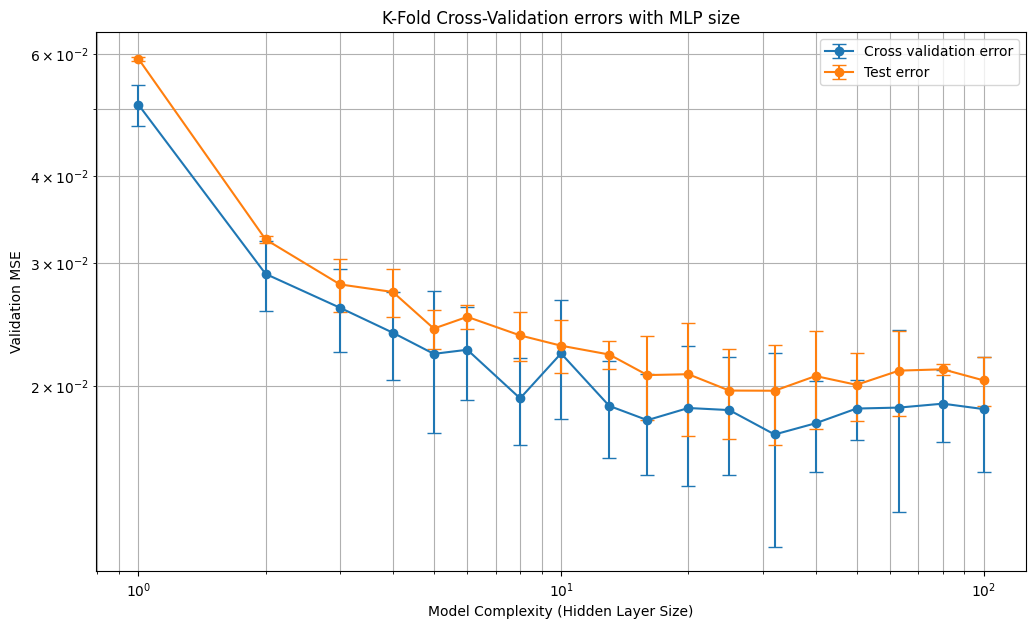

In [21]:
# Define hidden_sizes for double descent exploration
hidden_sizes = [1, 2, 3, 4, 5, 6, 8, 10, 13, 16, 20, 25, 32, 40, 50, 63, 80, 100]

# Execute k-fold cross validation for all sizes
mean_cv_errors, std_cv_errors, mean_test_errors, std_test_errors = vary_number_of_hidden_neurons(hidden_sizes)

# Plotting the results with error bars
plt.figure(figsize=(12, 7))
plt.errorbar(hidden_sizes, mean_cv_errors,   yerr=std_cv_errors,   fmt='o-', capsize=5, label='Cross validation error')
plt.errorbar(hidden_sizes, mean_test_errors, yerr=std_test_errors, fmt='o-', capsize=5, label='Test error')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Model Complexity (Hidden Layer Size)')
plt.ylabel('Validation MSE')
plt.title('K-Fold Cross-Validation errors with MLP size')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

## Final comments

1.  **Scaling:** Notice how fast the loss dropped? That is thanks to our $[-1, 1]$ scaling. Without it, the `Tanh` function would saturate immediately.
2.  **Early Stopping:** You likely saw the "Early stopping triggered" message. This saved us computing resources and prevented the model from memorizing the noise in the concrete data.